In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

# Mini-projet 6 : Atterrissage lunaire

Martin Desombre & Benoît Monnereau-Moinier

### Question 1

$$
v_y^{k+1} = v_y^k + \frac{\Delta t}{2}\left(a_y^k + a_y^{k+1}\right)
$$

$$
y^{k+1} = y^k + v_y^k\,\Delta t
+ \frac{\Delta t^2}{3} a_y^k
+ \frac{\Delta t^2}{6} a_y^{k+1}
$$

_(écriture LateX généré par IA)_

$$
J = \frac{\Delta t}{3}
\sum_{k=0}^{N-1} \Big[
(a_h^k)^2 + (a_h^{k+1})^2 + a_h^k a_h^{k+1}
+ (a_y^k)^2 + (a_y^{k+1})^2 + a_y^k a_y^{k+1}
\Big]
$$

_(écriture LateX généré par IA)_

### Question 4

In [2]:
def resolutionQ4(T, N, h0, vh0, y0, vy0, amax, grav):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [ca.inf]*nb
    lbx += [-ca.inf]*nb
    ubx += [ca.inf]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0] #ajout direct de la contrainte physique h>=0
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]-vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6)
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    g = ca.vertcat(*g)

    #cout
    J = (deltaT/3)
    for k in range(N):
        J+=ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1]
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    
    solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    return reponse, float(sol['f'])


In [3]:
#reponse, j = resolutionQ4(60*20, 20, 1000, -41, -1200, 10, 3, 1.62)

### Question 5

In [4]:
def resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit, silence=False):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [ca.inf]*nb
    lbx += [-ca.inf]*nb
    ubx += [ca.inf]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0] #ajout direct de la contrainte physique h>=0
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]-vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6)
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    #Question 5
    tangammacrit = np.tan(gammacrit*np.pi/180)
    for k in range(nb):
        g.append(y[k] - (h[k]*tangammacrit))
        g.append(-y[k] - (h[k]*tangammacrit))
        lbg.append(-ca.inf)
        ubg.append(0)
        lbg.append(-ca.inf)
        ubg.append(0)
    
    tanthetamax = np.tan(thetamax*np.pi/180)
    for k in range(nb):
        g.append(ay[k] - (ah[k]*tanthetamax))
        lbg.append(-ca.inf)
        ubg.append(0)
        g.append(-ay[k] - (ah[k]*tanthetamax))
        lbg.append(-ca.inf)
        ubg.append(0)
    
    g = ca.vertcat(*g)

    #cout
    J = (deltaT/3)
    for k in range(N):
        J+=ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1]
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    if silence: #pour clarifier les outpout
        solver = ca.nlpsol('s', 'ipopt', nlp, {"ipopt.print_level":0, "ipopt.sb":"yes", "print_time": 0})
    else:
        solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    return reponse, float(sol['f'])


In [5]:
#reponse, J = resolutionQ5(60*10, 20, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

### Question 6

In [6]:
import matplotlib.gridspec as gridspec #je suis allé personnelement chercher cette bibliothèque pour améliorer le rendu, je l'ai découverte sur https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html

In [ ]:
def tracés(T, N, h0, vh0, y0, vy0, amax, etha, m, grav, thetamax, gammacrit):
    deltaT = T/N
    temps = [i*deltaT for i in range(N+1)]
    #reponse, J = resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit)
    tanthetamax = np.tan(thetamax*np.pi/180)
    tangammacrit = np.tan(gammacrit*np.pi/180)
    
    fig = plt.figure(figsize=(8,8))
    gs = fig.add_gridspec(4, 3)
    ax1 = fig.add_subplot(gs[0,0])
    ax1.plot(temps, reponse['ah'], color= "b", label="ah(t)")
    ax1.plot(temps, [0 for i in range(N+1)], "--", color="b", label="ah min")

    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(temps, reponse['ay'], color = "y", label="ay(t)")
    
    ax3 = fig.add_subplot(gs[0,2])
    ax3.plot(temps, reponse['ay']**2+reponse['ah']**2, color = "r", label="ay^2(t) + ah^2(t)")
    ax3.plot(temps, [amax**2 for i in range(N+1)], "+", color = "r", label="amax^2")
    
    for ax in [ax1, ax2, ax3]:
        ax.set_ylabel("m/s²")
        ax.set_xlabel("temps (s)")
    
    ax4 = fig.add_subplot(gs[1,:])
    ax4.plot(reponse['ay'], reponse['ah'], label="ah(ay)")
    arrayAY = np.squeeze(reponse['ay'].full()) #parceque numpy c'est quand même plus pratique et que le rendu en array avait une dimension en trop
    abscisseAY = np.linspace(np.min(arrayAY), np.max(arrayAY))
    ax4.plot(abscisseAY,  np.abs(abscisseAY)/tanthetamax, label="attitude max")
    ax4.set_ylabel("m/s²")
    ax4.set_xlabel("ay (m/s²)")

    ax5 = fig.add_subplot(gs[2,:])
    ax5.plot(reponse['y'], reponse['h'], label="h(y)")
    arrayY = np.squeeze(reponse['y'].full())
    abscisseY = np.linspace(np.min(arrayY), np.max(arrayY))
    ax5.plot(abscisseY,  np.abs(abscisseY)/tangammacrit, label="Cône d'aterissage")
    #ax5.plot(reponse['y'], ca.fabs(reponse['y'])/tangammacrit, label="Cône d'aterissage")
    ax5.set_ylabel("m")
    ax5.set_xlabel("y (m)")

    ax6 = fig.add_subplot(gs[3,0])
    ax6.plot(temps, np.sqrt(reponse['ah']**2+reponse['ay']**2)*m/etha, label="q(t)")
    #par la contrainte h >= 0 on a nessessairement theta dans -pi/2:pi/2 d'où l'usage d'arctangente:
    ax6.set_xlabel("temps (s)")
    ax6.set_ylabel("m^3/s")
    
    ax7 = fig.add_subplot(gs[3,1])
    ax7.plot(temps, np.arctan(reponse['ay']/reponse['ah']), label="theta(t)")
    ax7.set_xlabel("temps (s)")
    ax7.set_ylabel("rad")
    '''
    #courbes supplémentaires
    axs[2,0].plot(temps, reponse['h'], label="h(t)")
    axs[2,0].set_ylabel("m")
    axs[2,0].set_xlabel("temps (s)")
    axs[2,0].legend()
    axs[2,1].plot(temps, reponse['y'], label="y(t)")
    axs[2,1].set_ylabel("m")
    axs[2,1].set_xlabel("temps (s)")
    '''
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]: 
        for j in [0,1,2]:
            ax.legend()

    plt.tight_layout()
    plt.show()

Resolution du problème décrit en question 4 : 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      331
Number of nonzeros in inequality constraint Jacobian.:       42
Number of nonzeros in Lagrangian Hessian.............:       82

Total number of variables............................:      118
                     variables with only lower bounds:       40
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       80
Total number of inequality c

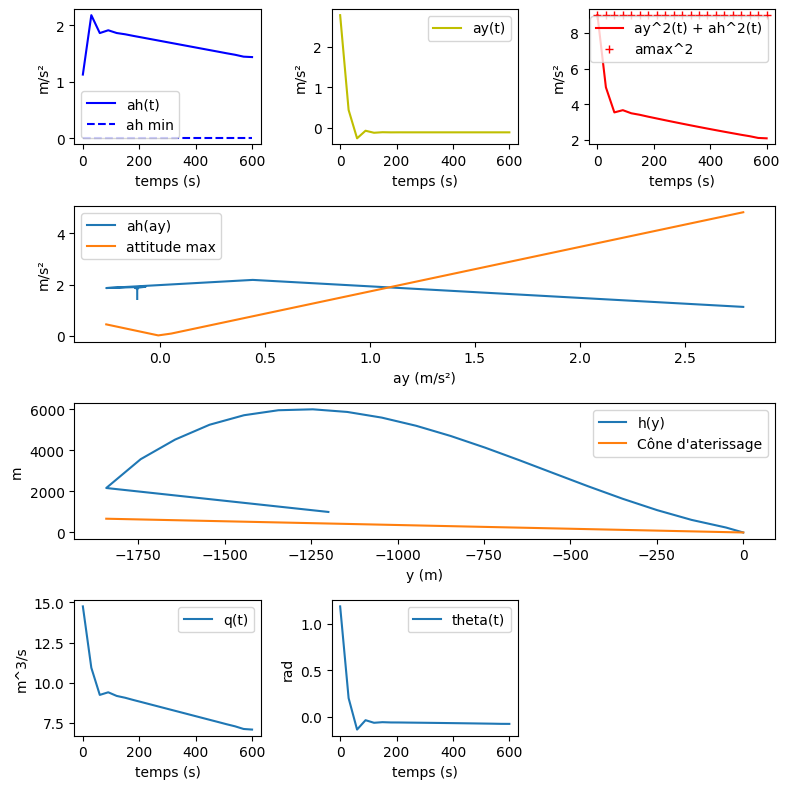

coût J = 192.78514401698231


In [8]:
reponse, J = resolutionQ4(60*10, 20, 1000, -41, -1200, 10, 3, 1.62)
tracés(60*10, 20, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)
print("coût J = "+ str(float(J)))

Resolution du problème avec les contraintes ajoutées question 5 :

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      331
Number of nonzeros in inequality constraint Jacobian.:      202
Number of nonzeros in Lagrangian Hessian.............:       82

Total number of variables............................:      118
                     variables with only lower bounds:       40
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       80
Total number of inequality constraints...............:      105
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       21
        inequality constraints with only upper bounds:       84

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3000000e+02 1.95e+03 1.40e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

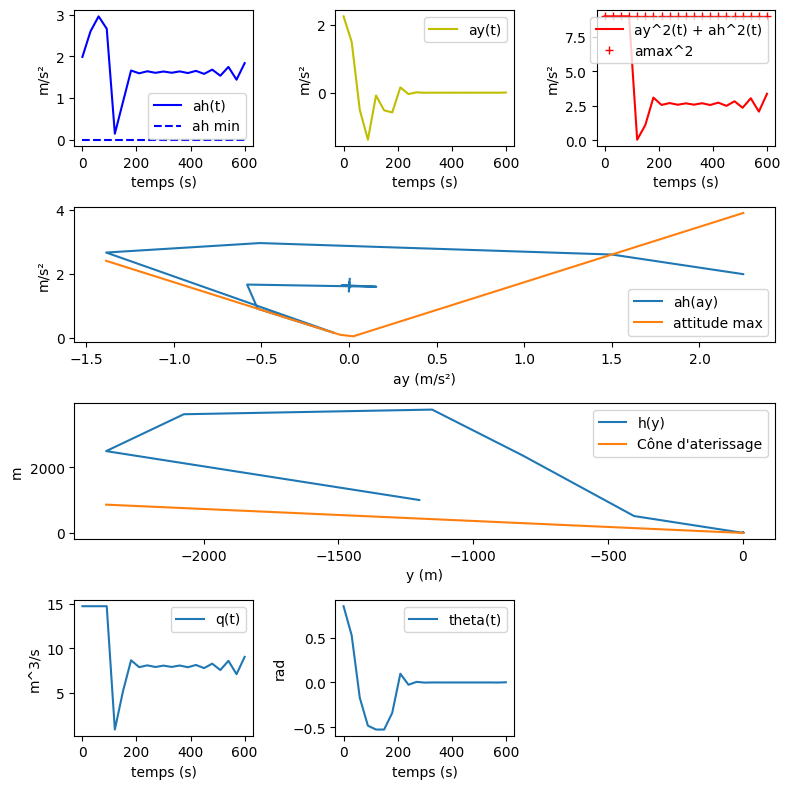

coût J = 215.45430211641553


In [9]:
reponse, J = resolutionQ5(60*10, 20, 1000, -41, -1200, 10, 3, 1.62, 30, 70)
tracés(60*10, 20, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)
print("coût J = "+ str(float(J)))

On observe une augmentation du coût avec l'ajout de nouvelles contraintes ce qui est cohérent. <br>
Il reste également la contrainte d'attitude qui n'est pas vérifié à t = 0.

### Question 7

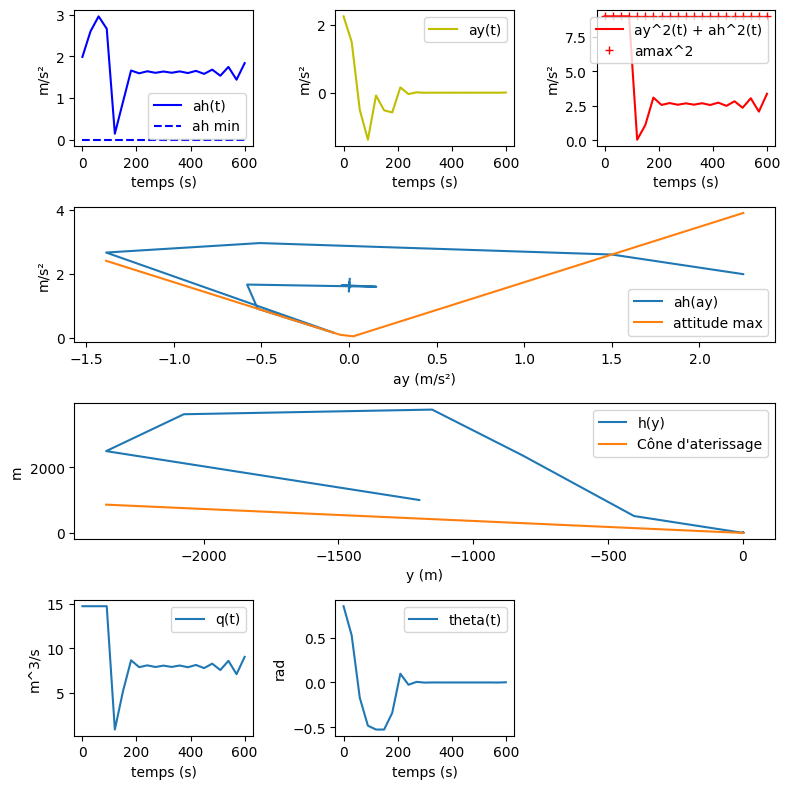

vh0, vy0 = (-41, 10)


In [11]:
reponse, J = resolutionQ5(60*10, 20, 1000, -41, -1200, 10, 3, 1.62, 30, 70, True)
tracés(60*10, 20, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)
print("vh0, vy0 = (-41, 10)")

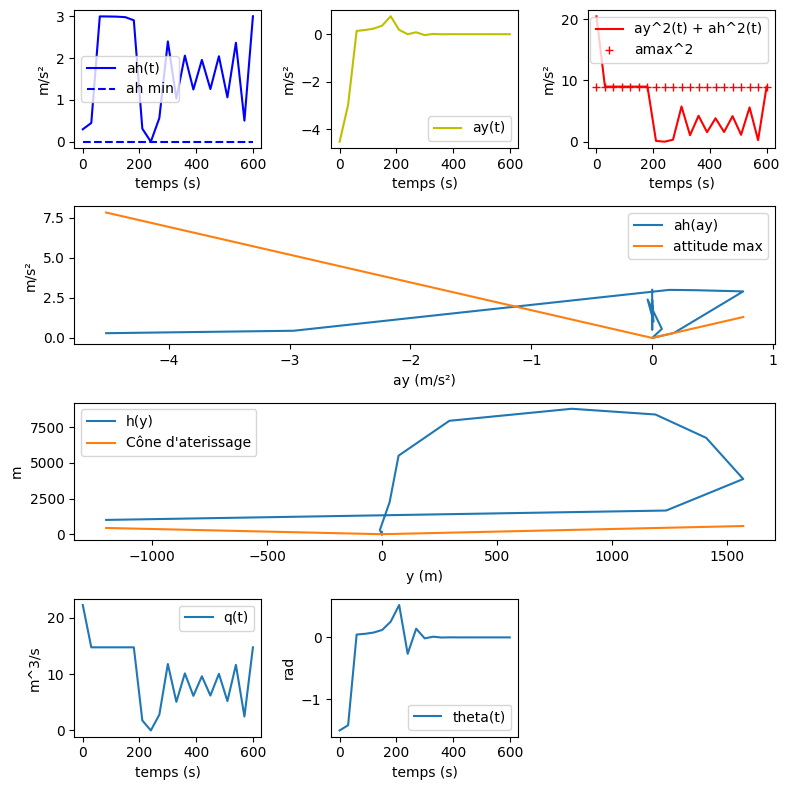

vh0, vy0 = (-41, 100)


In [18]:
reponse, J = resolutionQ5(60*10, 20, 1000, -41, -1200, 100, 3, 1.62, 30, 70, True)
tracés(60*10, 20, 1000, -41, -1200, 100, 3,3050, 15000, 1.62, 30, 70)
print("vh0, vy0 = (-41, 100)")

avec une vitesse initiale abbérante on obtient des resultats abérants. <br> C'est quand même bizarre que les contraintes d'attitudes max et d'accélération max ne soient pas respectées.

### Question 8

In [33]:
def question8(N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit):
    listeJ = []
    listeT = np.linspace(3, 40, 300) #en minutes
    for T in listeT:
        reponse ,J = resolutionQ5(T*60, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit, True)
        listeJ.append(J)
    plt.plot(listeT, listeJ)
    plt.xlabel("T en minutes")
    plt.ylabel("J")
    plt.title("F(T) pour un attérissage lunaire proche des missions Apollo")
    plt.legend()
    plt.show()

C:\Users\Benoi\AppData\Local\Temp\ipykernel_11576\1891878686.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


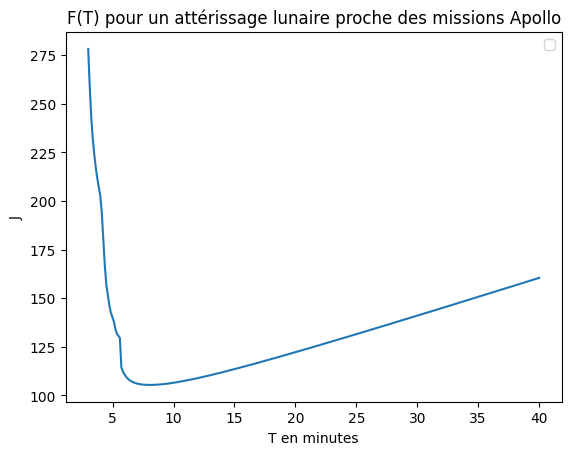

In [34]:
question8(10, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

On a volontairement limité la borne inférieur du temps à 3 minutes pour éviter les effet abérants dû à des contraintes de temps de vol abérantes et garantir l'existence d'une solution. <br>
On observe qu'un minimum se déssine autour de 7 minutes.

### Question 9

Grâce à l'observation de la courbe, on peut restreindre la zone de recherche à l'intervalle [5:10]. <br>
On observe de plus que la fonction est unimodale sur [5:10].<br>
On va donc procéder avec la méthode de la section dorée, plus efficace que celle de dichotomie.



In [43]:
def F(T):
    reponse ,J = resolutionQ5(T*60, 10, 1000, -41, -1200, 10, 3, 1.62, 30, 70, True)
    return J

def calcMemoisé(ram, f, x):
    if x in ram:
        return ram[x]
    else:
        ram[x] = f(x)
        return ram[x]

def sectionDoree(f,a,b, epsilon):
    tau = (np.sqrt(5)-1)/2
    ram = {}
    while b-a > epsilon:
        fa = calcMemoisé(ram, f, a)
        fm1 = calcMemoisé(ram, f, a + (1-tau)*(b-a))
        fm2 = calcMemoisé(ram, f, a + tau*(b-a))
        fb = calcMemoisé(ram, f, b)
        if fa > fm1 and fm1 < fm2 :
            b = a + tau*(b-a)
        elif fm1 > fm2 and fm2 < fb:
            a = a + (1-tau)*(b-a)
        else :
            print("PROUT")
    return (a+b)/2


In [44]:
sectionDoree(F, 5, 10, 0.001)

np.float64(8.080675190994498)